# Test to get this 'Csordas' subnetwork method working

# NO NORMALIZATION, SCALING [0, 1], Train and Test set used

In [1]:
import torch
import torchvision
import framework
import tasks
import os

path = "./save/cifar10/checkpoint/model-220011.pth"
test = torch.load(path, weights_only=False)

# Fake-run the test command to populate 'sys.argv'

import shlex
import sys

# cmd = "main.py -name cifar10_Tr50k_Te10K_split_one_mask_per_class -task cifar10_class_removal -stop_after 20000 -mask_loss_weight 3e-4 -mask_lr 1e-3 -step_per_mask 20000 -class_removal.keep_last_layer 1 -dropout 0.0 -cnn.dropout 0 -restore_pretrained ./save/cifar10/model_weights"
cmd = "main.py -name cifar10_Tr50k_Te10K_split_one_mask_per_class -task cifar10_class_removal -stop_after 20000 -mask_loss_weight 3e-4 -mask_lr 1e-3 -step_per_mask 20000 -class_removal.keep_last_layer 1 -dropout 0.0 -cnn.dropout 0"
cmd_args = shlex.split(cmd)
sys.argv = cmd_args

print(cmd_args)

['main.py', '-name', 'cifar10_Tr50k_Te10K_split_one_mask_per_class', '-task', 'cifar10_class_removal', '-stop_after', '20000', '-mask_loss_weight', '3e-4', '-mask_lr', '1e-3', '-step_per_mask', '20000', '-class_removal.keep_last_layer', '1', '-dropout', '0.0', '-cnn.dropout', '0']


In [2]:
from main import register_args, load_weights, save_weights

training_helper = framework.helpers.TrainingHelper(
    wandb_project_name="modules",
    register_args=register_args, 
    extra_dirs=["export", "model_weights"])

def invalid_task_error(self):
    assert False, f"Invalid task: {training_helper.opt.task}"

constructors = {
    "tuple": tasks.TupleTask,
    "tuple_ff": tasks.TupleTaskFeedforward,
    "scan": tasks.ScanTask,
    "trafo_scan": tasks.TransformerScanTask,
    "addmul_ff": tasks.AddMulFeedforward,
    "addmul": tasks.AddMulTask,
    "cifar10_class_removal": tasks.Cifar10ClassRemovalTask,
    "cifar10_resnet_hp_class_removal": tasks.Cifar10ResnetHPClassRemovalTask,
    "cifar10_mask_stability": tasks.Cifar10MaskStabilityTask,
    "cifar10_grad_cos_distance": tasks.Cifar10GradCosDistanceTask,
    "permuted_mnist": tasks.PermutedMnistTask,
    "deepmind_math": tasks.DeepmindMathTask,
    "tuple_ff_copyweight": tasks.TupleFeedforwardCopyweightTask
}

task = constructors.get(training_helper.opt.task, invalid_task_error)(training_helper)

There is no more free GPUs. Allocating the one with least memory usage.
#########################
DROPOUT:
False
#########################
Found module parameters: ['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight']
Masking is applied to paramteres: {'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_10_weight', 'features_10_bias', 'features_6_weight', 'out_layer_weight', 'features_0_bias', 'out_layer_bias', 'features_0_weight'}
Masking 390986 out of 390986 parameters (100.0 %)


/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


In [3]:
if training_helper.opt.restore_pretrained:
    assert not task.helper.opt.train_baseline
    load_weights(training_helper, task)
    if training_helper.opt.test_pretrained:
        training_helper.summary.log({f"load_validation/{k}": v for k, v in task.validate().items()})
    print("Done. Skipping training...")
else:
    if task.helper.opt.train_baseline:
        task.set_baseline_mode()

    task.train()

    print("Training finished. Saving model...")
    save_weights(training_helper, task)

Now batch number: 0
Now batch number: 500


100%|██████████| 79/79 [00:00<00:00, 153.16it/s]


Validation accuracy on iid: 0.5377


100%|██████████| 79/79 [00:00<00:00, 143.70it/s]


Validation accuracy on train: 0.54
Now batch number: 1000
Now batch number: 1500


...

Validation accuracy on train: 0.9785
Now batch number: 19000
Now batch number: 19500


100%|██████████| 79/79 [00:00<00:00, 164.73it/s]


Validation accuracy on iid: 0.7658


100%|██████████| 79/79 [00:00<00:00, 168.71it/s]


Validation accuracy on train: 0.9809
Training finished. Saving model...


In [4]:
if task.helper.opt.analysis.enable and not task.helper.opt.train_baseline:
    task.post_train_2()

100%|██████████| 79/79 [00:00<00:00, 143.32it/s]


Validation accuracy on iid: 0.7658


100%|██████████| 79/79 [00:00<00:00, 169.04it/s]


Validation accuracy on train: 0.9809
stage / mask_id: 0 / -1
Set: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ----> Mask class: -1


/home/Raffew/miniconda3/envs/csordas_test/lib/python3.12/site-packages/torch/utils/data/sampler.py:74: UserWarning: `data_source` argument is not used and will be removed in 2.2.0.You may still have custom implementation that utilizes it.
  warnings.warn(


...

100%|██████████| 79/79 [00:00<00:00, 172.70it/s]


Validation accuracy on iid: 0.1


100%|██████████| 79/79 [00:00<00:00, 195.56it/s]


Validation accuracy on train: 0.1014
Now mask step: 19990 (iter: 240000, start: 220010)


100%|██████████| 79/79 [00:00<00:00, 181.68it/s]


In [6]:
for i in range(len(task.model.masks)):
    print(f"Mask {i}: {task.model.masks[i].keys()}")

Mask 0: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 1: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 2: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 3: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 'features_3_weight', 'features_6_bias', 'features_6_weight', 'out_layer_bias', 'out_layer_weight'])
Mask 4: dict_keys(['features_0_bias', 'features_0_weight', 'features_10_bias', 'features_10_weight', 'features_3_bias', 

In [7]:
# step = 10 # Number of "layers" per 'mask-dict'
# loaded_masks = torch.nn.ModuleList([torch.nn.ParameterDict({layer_name: torch.nn.Parameter(mask_params) 
#  for (layer_name, _), (long_layer_name, mask_params) in zip(task.model.model_parameters.items(), list(test["model"].items())[step+i*step:i*step+step+step])
#  if task.mask_filter(layer_name)})
#  for i in range(task.get_n_masks())
#     ])

# task.model.masks = loaded_masks

  0%|          | 0/79 [00:00<?, ?it/s]

100%|██████████| 79/79 [00:00<00:00, 143.47it/s]


Validation accuracy on iid: 0.6992


100%|██████████| 79/79 [00:00<00:00, 157.42it/s]


Validation accuracy on train: 0.7639


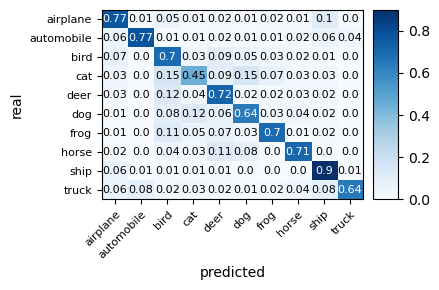

In [8]:
%matplotlib inline

import matplotlib.pyplot as plt

a = {f"validation/{k}": v for k, v in task.validate().items() if k.endswith("/confusion")}

a["validation/iid/confusion"].to_matplotlib()
plt.show()

In [9]:
task.validate().items()

100%|██████████| 79/79 [00:00<00:00, 145.69it/s]


Validation accuracy on iid: 0.6992


100%|██████████| 79/79 [00:00<00:00, 155.53it/s]

Validation accuracy on train: 0.7639


dict_items([('iid/loss', 1.1093453880310058), ('iid/accuracy', 0.6992), ('iid/confusion', <framework.visualize.plot.ConfusionMatrix object at 0x7f7cca136690>), ('train/loss', 0.40362975330289447), ('train/accuracy', 0.7639), ('train/confusion', <framework.visualize.plot.ConfusionMatrix object at 0x7f7cdba16210>), ('mean_accuracy', 0.73155), ('mean_loss', 0.7564875706669502)])

In [10]:
stage = 0
task.model.set_active(stage)
test, b = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid) 

confusion = test.confusion.type(torch.float32)
confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
if stage == 0:
    confusion_ref = confusion

100%|██████████| 79/79 [00:00<00:00, 158.40it/s]


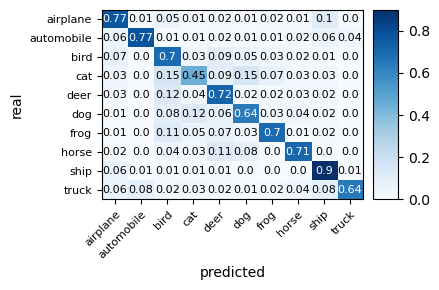

In [11]:
task.draw_confusion_heatmap(confusion_ref).to_matplotlib()
plt.show()

100%|██████████| 79/79 [00:00<00:00, 128.40it/s]


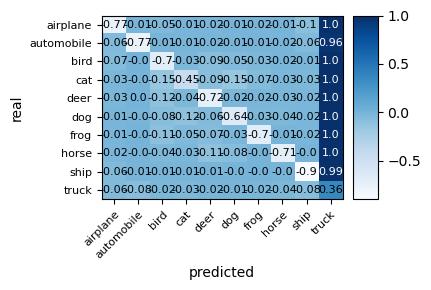

In [12]:
stage = 2
task.model.set_active(stage)
test, b = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
confusion = test.confusion.type(torch.float32)
confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
diff = confusion - confusion_ref

task.draw_confusion_heatmap(diff).to_matplotlib()
plt.show()

In [13]:
model_1 = task.model.masks[0]

# Count total parameters (for comparison)
total_params = sum(p.numel() for p in model_1.parameters() if p.requires_grad)
# Count only nonzero parameters
nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

print(f"Total parameters:           {total_params:,}")
print(f"Nonzero parameters:         {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

Total parameters:           390,986
Nonzero parameters:         169,381 --- 43.32%


In [14]:
task.valid_sets

{'iid': <dataset.image.cifar.CIFAR10 at 0x7f7d06792330>,
 'train': <dataset.image.cifar.CIFAR10 at 0x7f7cca56c4a0>}

In [15]:
task.prepare_model_for_analysis()

# count = 0
for stage, mask_id in enumerate([-1]+task.mask_classes):
    # if count > 1:
    #     break
    # count += 1
    split = "baseline" if stage==0 else task.train_set.class_names[mask_id]

    task.model.set_active(stage)

    # set = task.create_restricted_train_set([i for i in range(task.train_set.n_classes) if i != mask_id])
    # if mask_id == -1:
    #     include_classes = [i for i in range(task.train_set.n_classes) if i != mask_id]
    # else:
    #     include_classes = [mask_id]

    # set = task.create_restricted_train_set(include_classes)
    # task.create_validate_on_train(set)

    print(f"stage/mask_id: {stage}/{mask_id}")

    model_1 = task.model.masks[stage]
    nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

    print(f"Nonzero parameters:   {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

    # If mask is finished training
    # test, _ = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
    # print(f"Self-class accuracy: {test.accuracy}")

    print("#######################")
        

stage/mask_id: 0/-1
Nonzero parameters:   169,381 --- 43.32%
#######################
stage/mask_id: 1/0
Nonzero parameters:   132,000 --- 33.76%
#######################
stage/mask_id: 2/1
Nonzero parameters:   3,725 --- 0.95%
#######################
stage/mask_id: 3/2
Nonzero parameters:   119,172 --- 30.48%
#######################
stage/mask_id: 4/3
Nonzero parameters:   107,650 --- 27.53%
#######################
stage/mask_id: 5/4
Nonzero parameters:   127,256 --- 32.55%
#######################
stage/mask_id: 6/5
Nonzero parameters:   109,488 --- 28.0%
#######################
stage/mask_id: 7/6
Nonzero parameters:   126,209 --- 32.28%
#######################
stage/mask_id: 8/7
Nonzero parameters:   140,254 --- 35.87%
#######################
stage/mask_id: 9/8
Nonzero parameters:   8,178 --- 2.09%
#######################
stage/mask_id: 10/9
Nonzero parameters:   2,011 --- 0.51%
#######################


In [16]:
len(task.valid_sets.iid)

10000

stage/mask_id: 0/-1
Nonzero parameters:   169,381 --- 43.32%


100%|██████████| 79/79 [00:00<00:00, 151.09it/s]


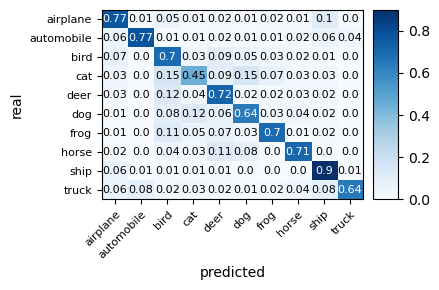

stage/mask_id: 1/0
Nonzero parameters:   132,000 --- 33.76%


100%|██████████| 79/79 [00:00<00:00, 141.71it/s]


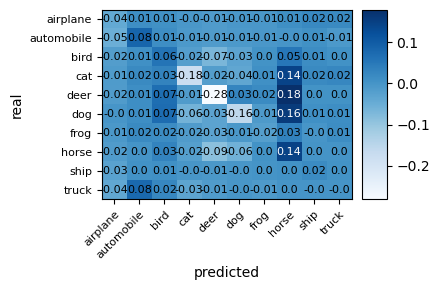

stage/mask_id: 2/1
Nonzero parameters:   3,725 --- 0.95%


100%|██████████| 79/79 [00:00<00:00, 156.60it/s]


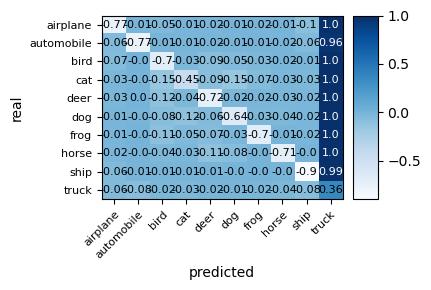

stage/mask_id: 3/2
Nonzero parameters:   119,172 --- 30.48%


100%|██████████| 79/79 [00:00<00:00, 158.05it/s]


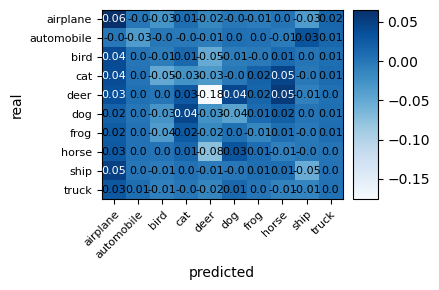

stage/mask_id: 4/3
Nonzero parameters:   107,650 --- 27.53%


100%|██████████| 79/79 [00:00<00:00, 145.98it/s]


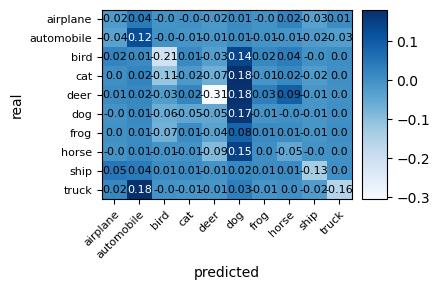

stage/mask_id: 5/4
Nonzero parameters:   127,256 --- 32.55%


100%|██████████| 79/79 [00:00<00:00, 155.59it/s]


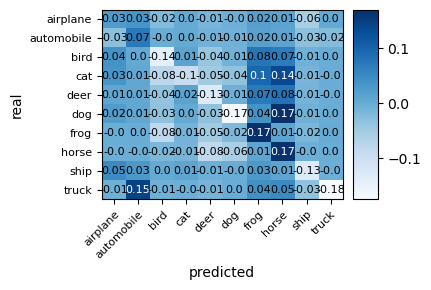

stage/mask_id: 6/5
Nonzero parameters:   109,488 --- 28.0%


100%|██████████| 79/79 [00:00<00:00, 153.95it/s]


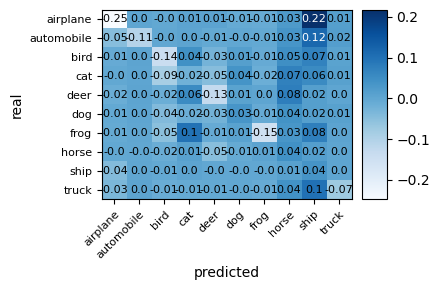

stage/mask_id: 7/6
Nonzero parameters:   126,209 --- 32.28%


100%|██████████| 79/79 [00:00<00:00, 153.42it/s]


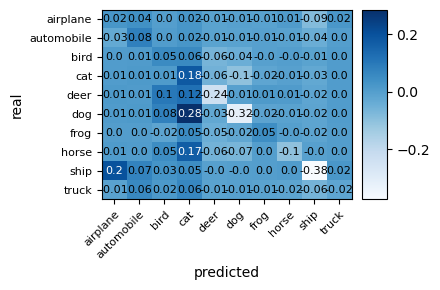

stage/mask_id: 8/7
Nonzero parameters:   140,254 --- 35.87%


100%|██████████| 79/79 [00:00<00:00, 141.79it/s]


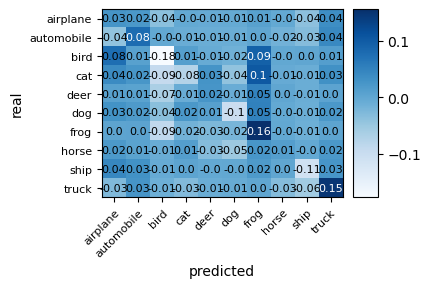

stage/mask_id: 9/8
Nonzero parameters:   8,178 --- 2.09%


100%|██████████| 79/79 [00:00<00:00, 144.34it/s]


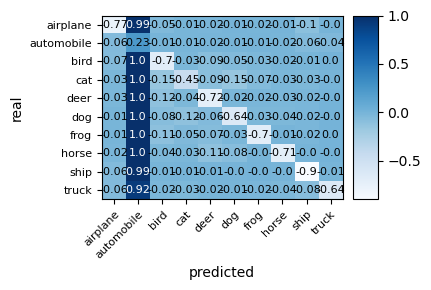

stage/mask_id: 10/9
Nonzero parameters:   2,011 --- 0.51%


100%|██████████| 79/79 [00:00<00:00, 150.71it/s]


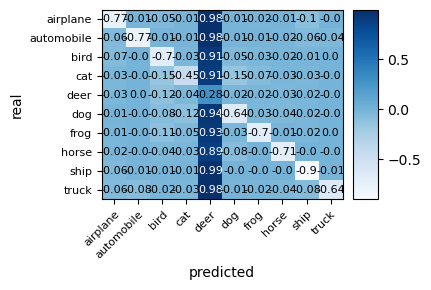

In [17]:
task.prepare_model_for_analysis()


for stage, mask_id in enumerate([-1]+task.mask_classes):
    split = "baseline" if stage==0 else task.train_set.class_names[mask_id]

    task.model.set_active(stage)

    # set = task.create_restricted_train_set([i for i in range(task.train_set.n_classes) if i != mask_id])
    # task.create_validate_on_train(set)

    print(f"stage/mask_id: {stage}/{mask_id}")

    model_1 = task.model.masks[stage]
    nonzero_params = sum((p > 0).sum().item() for p in model_1.parameters() if p.requires_grad)

    print(f"Nonzero parameters:   {nonzero_params:,} --- {round(100 * (nonzero_params / total_params), 2)}%")

    # If mask is finished training
    test, _ = task.validate_on(task.valid_sets.iid, task.valid_loaders.iid)
    confusion = test.confusion.type(torch.float32)
    confusion = (confusion / confusion.sum(dim=0, keepdim=True)).transpose(1, 0)
    # Have a reference mask which is all the classes?
    if stage == 0:
        confusion_ref = confusion
        task.draw_confusion_heatmap(confusion_ref).to_matplotlib()
        plt.show()
    else:
        diff = confusion - confusion_ref
        task.draw_confusion_heatmap(diff).to_matplotlib()
        plt.show()

In [15]:
from pathlib import Path

rundir = "./save/cifar10/export/stage_final_masks/"

In [16]:
p = Path(Path.cwd() / rundir)
p

PosixPath('/home/Raffew/Projects/Csordas_modules/save/cifar10/export/stage_final_masks')

In [17]:
num_folders = len([1 for entry in Path(rundir).iterdir() if entry.is_dir()])
num_folders

11

In [18]:
for stage in range(num_folders):
    weights = [torch.load(w, weights_only=False).reshape(-1) for w in Path().glob(f"{rundir}/stage_{stage}/**/*.pth")]
    print(weights)
    break

[array([ 2.6369717 ,  4.2277794 ,  0.32757622,  3.3867707 ,  2.202412  ,
        2.7907357 ,  3.9601774 ,  3.8849027 , -0.87059575,  3.628717  ,
        4.8582044 ,  3.914536  ,  3.7285867 ,  4.91843   ,  0.96754944,
        3.8703272 ,  4.6419497 ,  2.9565852 ,  5.281751  ,  2.3181372 ,
       -0.9727629 ,  3.207938  ,  4.378098  ,  4.164818  ,  4.1138935 ,
        1.380721  ,  4.4770722 ,  0.7525988 ,  4.090915  ,  5.2594066 ,
        2.1235492 ,  3.7790024 ], dtype=float32), array([  2.7225559 ,   3.02551   ,   2.849883  ,   2.5457292 ,
       -14.275013  ,   2.276333  ,   3.0462253 ,   3.1276858 ,
         1.4251386 ,   2.1693234 ,   2.608265  ,   2.3473783 ,
         1.5338578 ,   2.5995681 ,   1.6134914 ,   3.4293299 ,
         3.0120208 ,   2.8966882 ,   2.6364508 ,   2.8086507 ,
         3.1172192 ,   2.316188  ,   2.3552263 ,   2.4949074 ,
         3.074001  ,   3.0390007 ,   2.8033593 ,   3.5945482 ,
         3.423007  ,   1.5939145 ,   1.5494925 ,   2.4914427 ,
         2.97

In [24]:
for x in task.model.masks[0].parameters():
    print(x)

Parameter containing:
tensor([ 2.6370,  4.2278,  0.3276,  3.3868,  2.2024,  2.7907,  3.9602,  3.8849,
        -0.8706,  3.6287,  4.8582,  3.9145,  3.7286,  4.9184,  0.9675,  3.8703,
         4.6419,  2.9566,  5.2818,  2.3181, -0.9728,  3.2079,  4.3781,  4.1648,
         4.1139,  1.3807,  4.4771,  0.7526,  4.0909,  5.2594,  2.1235,  3.7790],
       device='cuda:0', requires_grad=True)
Parameter containing:
tensor([[[[  2.7226,   3.0255,   2.8499],
          [  2.5457, -14.2750,   2.2763],
          [  3.0462,   3.1277,   1.4251]],

         [[  2.1693,   2.6083,   2.3474],
          [  1.5339,   2.5996,   1.6135],
          [  3.4293,   3.0120,   2.8967]],

         [[  2.6365,   2.8087,   3.1172],
          [  2.3162,   2.3552,   2.4949],
          [  3.0740,   3.0390,   2.8034]]],


        [[[  3.5945,   3.4230,   1.5939],
          [  1.5495,   2.4914,   2.9793],
          [  2.3863,   2.9125,   1.7734]],

         [[  3.6370,   3.6746,   1.5607],
          [  1.9315,   3.3054,   2.

# NOTES

When looking at the 11 "masks", the first mask is a mask made to "keep" the output and last layer. Look into "def class_removal_init_masks_and_optim" to see the usage. 

Only dataloaders have a random seed "set", but that is still randomized.

They loos quite a lot of performance in their subnetworks, if i understand their confusion matrices correctly.

Masks are initialized as "2.0" --> All masks start out the same.

The normalize the data with these tensor values:

MEAN:

    array([[[125.3069 ]],

        [[122.95015]],

        [[113.866  ]]], dtype=float32)

STD:

    array([[[62.992565]],

       [[62.08881 ]],

       [[66.70408 ]]], dtype=float32)

They never change the underlying model parameter values, they only do some "masking magic"